In [18]:
import geopandas as gpd
import pandas as pd
import ast
import gzip
import io
import zipfile
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import warnings
import spatialdata
import spatialdata_io
import geopandas as gpd
from shapely.geometry import Polygon, Point
from rtree import index
import numpy as np

In [19]:
# Utils 

# Define a function to calculate overlap percentage
def calculate_overlap(spot, annotation):
    # Calculate the intersection area
    intersection = spot.intersection(annotation)
    if intersection.is_empty:
        return 0
    else:
        # Calculate the area of overlap as a percentage of the spot's area
        return intersection.area / spot.area * 100

# Function to calculate overlap for each spot against annotations
def calculate_annotation_overlap(gdf, data_exploded, spot_idx):
    n=0
    # Loop over unique annotations in the 'Annotation' column of data_exploded
    for annotation_name in data_exploded['Annotation'].unique():
        n+=1
        print(str(n)+'/'+str(len(data_exploded['Annotation'].unique()))+' layer of annotation processed')
        # Filter the annotations that correspond to the current group
        annotation_group = data_exploded[data_exploded['Annotation'] == annotation_name]

        # Dynamically create a column name for this annotation
        column_name = f"{annotation_name}_overlap"
        
        # Initialize the new column with NaNs (or zeros, depending on preference)
        if column_name not in gdf.columns:
            gdf[column_name] = np.nan

        # Loop over each annotation polygon in the current group
        for _, annotation_row in annotation_group.iterrows():
            annotation = annotation_row['geometry']

            # Find all spots that intersect with this annotation using the spatial index
            possible_spots = list(spot_idx.intersection(annotation.bounds))

            # Loop over possible spots and calculate overlap
            for spot_id in possible_spots:
                spot = gdf.loc[spot_id, 'geometry']
                overlap_percentage = calculate_overlap(spot, annotation)

                # Update the overlap percentage for the spot in the corresponding annotation column
                gdf.at[spot_id, column_name] = overlap_percentage
    
    # Fill NaN values with 0 after processing all annotations
    gdf.fillna(0, inplace=True)

    return gdf

In [23]:
class HistoMap:
    def __init__(self, file_name, visium_spatialdata):
        self.file_name = file_name
        self.visium_spatialdata = visium_spatialdata
        self.data = self.read_geojson_based_on_type(file_name)
        self.data_exploded = self.data.explode()
        self._extract_annotations()
        self.add_area_column()
        self.spot_geodata = self.generate_spot_geodata()
        self.overlay_computed = False

    def generate_spot_geodata(self):
        """Function to generate a dataframe from the spatialdata object as circle geodata"""
        # Extract spatial coordinates from the GeoDataFrame in the Shapes section
        image_id = list(self.visium_spatialdata.shapes.keys())[0] 
        coords = self.visium_spatialdata.shapes[image_id]  # GeoDataFrame with spot coordinates

        # Extract the spot diameter from the scalefactors and convert it to radius
        spot_radius = float(self.visium_spatialdata.shapes[image_id]['radius'][0])

        # Create circular polygons for each spot using the coordinates and radius
        gdf = gpd.GeoDataFrame(
            {"spot_id": range(len(coords))},  # Assign unique spot IDs
            geometry=[Point(x, y).buffer(spot_radius) for x, y in zip(coords.geometry.x, coords.geometry.y)],  # Buffer creates circle
            #crs="EPSG:4326"  # Uncomment and set CRS if necessary
        )
        return gdf

    def read_geojson_based_on_type(self, file_name):
        """Function to detect file type and read the file accordingly"""
        if file_name.endswith('.gz'):
            with gzip.open(file_name, 'rb') as f:
                return gpd.read_file(io.BytesIO(f.read()))
        elif zipfile.is_zipfile(file_name):
            with zipfile.ZipFile(file_name, 'r') as zip_ref:
                geojson_file = zip_ref.namelist()[0]
                with zip_ref.open(geojson_file) as f:
                    return gpd.read_file(f)
        elif file_name.endswith('.geojson'):
            return gpd.read_file(file_name)
        else:
            raise ValueError("Unsupported file format")

    def _extract_annotations(self):
        """Extract annotations from 'classification' column and compute area."""
        self.data_exploded['classification'] = self.data_exploded['classification'].apply(ast.literal_eval)
        self.data_exploded['Annotation'] = self.data_exploded['classification'].apply(lambda x: x.get('name', None))

    def add_area_column(self):
        """Adds an area column to the dataframe (in square units)."""
        self.data_exploded['area'] = self.data_exploded['geometry'].area

    def generate_summary(self):
        """Generates a summary DataFrame with various metrics."""
        summary = pd.DataFrame()

        # Compute total area, perimeter, mean aspect ratio, and other metrics
        summary['total_area'] = self.data_exploded.groupby('Annotation')['geometry'].apply(lambda x: x.area.sum())
        summary['total_perimeter'] = self.data_exploded.groupby('Annotation')['geometry'].apply(lambda x: x.length.sum())
        summary['mean_aspect_ratio'] = self.data_exploded.groupby('Annotation').apply(
            lambda x: (x.bounds.max(axis=1) - x.bounds.min(axis=1)).prod() / (x.bounds.max(axis=1) - x.bounds.min(axis=1)).sum())
        summary['mean_circularity'] = self.data_exploded.groupby('Annotation').apply(
            lambda x: 4 * 3.14159 * (x.area / x.length ** 2).mean())
        summary['centroid_x'] = self.data_exploded.groupby('Annotation')['geometry'].apply(lambda x: x.centroid.x.mean())
        summary['centroid_y'] = self.data_exploded.groupby('Annotation')['geometry'].apply(lambda x: x.centroid.y.mean())
        summary['mean_convex_hull_area'] = self.data_exploded.groupby('Annotation').apply(
            lambda x: x.convex_hull.area.mean())
        summary['mean_bounding_box_area'] = self.data_exploded.groupby('Annotation').apply(
            lambda x: ((x.bounds.max(axis=1) - x.bounds.min(axis=1)).prod()).mean())
        summary['mean_solidity'] = self.data_exploded.groupby('Annotation').apply(
            lambda x: (x.area / x.convex_hull.area).mean())
        summary['mean_extent'] = self.data_exploded.groupby('Annotation').apply(
            lambda x: (x.area / ((x.bounds.max(axis=1) - x.bounds.min(axis=1)).prod())).mean())
        summary['mean_compactness'] = self.data_exploded.groupby('Annotation').apply(
            lambda x: (x.length ** 2 / (4 * 3.14159 * x.area)).mean())

        # Compute area fraction, edge density, and polygon count
        total_area = self.data_exploded.geometry.area.sum()
        summary['area_fraction'] = summary['total_area'] / total_area
        summary['mean_edge_density'] = self.data_exploded.groupby('Annotation').apply(
            lambda x: x.length.sum() / x.area.sum())
        summary['polygon_count'] = self.data_exploded.groupby('Annotation').size()

        # Compute max and min areas and perimeters
        summary['max_area'] = self.data_exploded.groupby('Annotation')['geometry'].apply(lambda x: x.area.max())
        summary['min_area'] = self.data_exploded.groupby('Annotation')['geometry'].apply(lambda x: x.area.min())
        summary['max_perimeter'] = self.data_exploded.groupby('Annotation')['geometry'].apply(lambda x: x.length.max())
        summary['min_perimeter'] = self.data_exploded.groupby('Annotation')['geometry'].apply(lambda x: x.length.min())

        # Reset index for a clean summary table
        summary.reset_index(inplace=True)
        return summary

    def display_plot_order(self):
        """Displays the plot order for each annotation in the DataFrame.
        If plot_order doesn't exist, it assigns a default plot order based on alphabetical annotation."""
    
        print("Current Plot Order:")
    
        # Check if 'plot_order' exists in the dataframe
        if 'plot_order' in self.data_exploded.columns:
            # Sort by 'plot_order' if it exists
            sorted_data = self.data_exploded[['Annotation', 'plot_order']].sort_values(by='plot_order', ascending=False)
        else:
            # If 'plot_order' doesn't exist, create a default plot order based on alphabetical sorting of 'Annotation'
            # Assign a rank based on the alphabetical order of 'Annotation'
            self.data_exploded['plot_order'] = self.data_exploded['Annotation'].astype('category').cat.codes
        
            # Sort by the default 'plot_order'
            sorted_data = self.data_exploded[['Annotation', 'plot_order']].sort_values(by='plot_order', ascending=True)

        unique_annotations = sorted_data[['Annotation', 'plot_order']].drop_duplicates()
        # Sort by plot_order
        unique_annotations = unique_annotations.sort_values(by='plot_order', ascending=True)
        print(unique_annotations)



    def change_plot_order(self, order_list):
        """
        Changes the plot order in the DataFrame based on the provided list of annotations.
        The list must contain only existing annotations from the data, and unspecified annotations 
        will be plotted in alphabetical order after the specified ones.

        Parameters:
        - order_list: A list of annotations in the desired plot order (top first).
        """
        # Ensure all annotations in the order_list exist in the DataFrame
        valid_annotations = set(self.data_exploded['Annotation'].unique())
        invalid_annotations = set(order_list) - valid_annotations

        if invalid_annotations:
            raise ValueError(f"The provided order list contains invalid annotations: {', '.join(invalid_annotations)}. Available annotations are: {', '.join(valid_annotations)}.")

        # Find the unspecified annotations
        missing_annotations = list(valid_annotations - set(order_list))
    
        # If there are unspecified annotations, display a warning
        if missing_annotations:
            warnings.warn(f"The following annotations were unspecified and will be plotted in alphabetical order at the end: {', '.join(missing_annotations)}.")

        # Sort missing annotations alphabetically
        missing_annotations.sort()

        # Append missing annotations to the order_list
        order_list += missing_annotations

        # Create a dictionary mapping each annotation to its new plot order
        plot_order_dict = {annotation: idx for idx, annotation in enumerate(order_list)}

        # Map the annotations in the DataFrame to the new plot order
        self.data_exploded['plot_order'] = self.data_exploded['Annotation'].map(plot_order_dict)

        # Sort by 'plot_order' in ascending order to plot top annotations first
        self.data_exploded = self.data_exploded.sort_values('plot_order', ascending=True)

        # Display the updated plot order
        self.display_plot_order()
        
    def plot_annotations(self, fill=None, contour=None):
        """Plots the annotations based on the DataFrame, respecting the plot order.
        If `fill=False`, no fill will be used (only contours). 
        If `fill=True`, it uses the default colormap ('tab20') for filling.
        If `fill` is a list of colors, it will be used to fill annotations (must match the length of annotations).
        If `contour` is provided, it will set the contour color for the annotations.

        Parameters:
        - fill: False, True, or a list of colors. 
                False means no fill (only contours), 
                True uses the default colormap for fill, 
                a list of colors specifies the fill color for each annotation.
        - contour: a color or list of colors for the contours. If None, the default colormap is used.
        """
        fig, ax = plt.subplots(figsize=(10, 10))

        # Use the new way of accessing colormaps in Matplotlib
        cmap = plt.cm.get_cmap('tab20')

        # If fill is True, set it to the default cmap
        if fill is True:
            fill = [cmap(idx % 20) for idx in range(len(self.data_exploded['Annotation'].unique()))]

        # If fill is a list, ensure it's the right length
        if isinstance(fill, list):
            if len(fill) != len(self.data_exploded['Annotation'].unique()):
                raise ValueError("The length of the 'fill' list must match the number of unique annotations.")
        
        # If fill is False, set it to an empty list (no fill color)
        if fill is False:
            fill = [None] * len(self.data_exploded['Annotation'].unique())

        # If contour is None, set it to the default cmap
        if contour is None:
            contour = [cmap(idx % 20) for idx in range(len(self.data_exploded['Annotation'].unique()))]
        # If contour is a list, ensure it's the right length
        elif isinstance(contour, list):
            if len(contour) != len(self.data_exploded['Annotation'].unique()):
                raise ValueError("The length of the 'contour' list must match the number of unique annotations.")
        # If contour is a single color, convert it to a list for uniformity
        elif isinstance(contour, str):
            contour = [contour] * len(self.data_exploded['Annotation'].unique())

        # Plot the annotations with respective colors
        for idx, row in self.data_exploded.iterrows():
            geom = row['geometry']
            annotation = row['Annotation']
            
            if geom.is_empty or not geom.is_valid:
                continue
            
            # Get the fill color from 'fill' list based on annotation index
            if isinstance(fill, list):
                fill_color = fill[self.data_exploded['Annotation'].unique().tolist().index(annotation)]
            else:
                fill_color = fill[idx] if fill is not None else None  # For True or default cmap behavior, if fill is None, don't assign color

            # Get the contour color from 'contour' list based on annotation index
            contour_color = contour[self.data_exploded['Annotation'].unique().tolist().index(annotation)]

            # Check if the geometry is a Polygon or MultiPolygon
            if geom.geom_type == 'Polygon':
                x, y = geom.exterior.xy
                if fill_color:  # If fill color is provided
                    ax.fill(x, y, color=fill_color, edgecolor=contour_color, label=annotation)
                else:  # If no fill (only contours)
                    ax.plot(x, y, color=contour_color, label=annotation)
            elif geom.geom_type == 'MultiPolygon':
                for polygon in geom:
                    x, y = polygon.exterior.xy
                    if fill_color:  # If fill color is provided
                        ax.fill(x, y, color=fill_color, edgecolor=contour_color, label=annotation)
                    else:  # If no fill (only contours)
                        ax.plot(x, y, color=contour_color, label=annotation)

        ax.set_title('Annotations', fontsize=14)
        ax.set_ylim(ax.get_ylim()[::-1])  # Reverse the y-axis to match latitude/longitude
        ax.set_aspect('auto')

        handles, labels = ax.get_legend_handles_labels()
        by_label = dict(zip(labels, handles))
        ax.legend(by_label.values(), by_label.keys(), bbox_to_anchor=(1, 1))

        # Adjust plot limits to the bounds of the data
        bounds = self.data_exploded.total_bounds
        ax.set_xlim(bounds[0], bounds[2])
        ax.set_ylim(bounds[1], bounds[3])
        plt.gca().invert_yaxis()
        plt.tight_layout()
        plt.show()

    def compute_overlap_annotation(self):
        """Compute and add overlap to the annotation_geodataframe"""
        # Create a spatial index for the spots
        spot_idx = index.Index()
        
        # Add spots to the spatial index
        for i, spot in self.spot_geodata.iterrows():
            spot_idx.insert(i, spot.geometry.bounds)

        self.spot_geodata = calculate_annotation_overlap(self.spot_geodata, self.data_exploded, spot_idx)
        self.overlay_computed = True

    def plot_annotation_overlay(self, annotation):
        if self.overlay_computed is False:
            raise ValueError("Error: compute annotation overlay with Visium spot using compute_overlap_annotation() first")
        # Ensure 'Positive_overlap' is in the correct format (float or int) for coloring
        gdf = self.spot_geodata.copy()
        gdf['Positive_overlap'] = self.spot_geodata[str(annotation)+'_overlap'].astype(float)

        # Plot the spots with colors based on 'Positive_overlap'
        fig, ax = plt.subplots(figsize=(10, 10))  # Adjust the figure size as needed

        # Plot the polygons with a colormap based on the 'Positive_overlap'
        gdf.plot(ax=ax, column='Positive_overlap', cmap='viridis', legend=True,
         legend_kwds={'label': "Positive Overlap (%)",
                      'orientation': "horizontal"})

        # Set title and axis labels (optional)
        ax.set_title('Spot Plot Colored by Positive Overlap', fontsize=15)
        ax.set_xlabel('X Coordinate', fontsize=12)
        ax.set_ylabel('Y Coordinate', fontsize=12)

        # Show plot
        plt.show()
    def plot_annotation_order(self, fill=None, contour=None, elevation_factor=1.0):
        """
        Plots the annotations in 3D space based on their plot order.
        Annotations with higher plot order will appear higher in the z-axis.
        
        Parameters:
        - fill: False, True, or a list of colors. 
                False means no fill (only contours), 
                True uses the default colormap for fill, 
                a list of colors specifies the fill color for each annotation.
        - contour: a color or list of colors for the contours. If None, the default colormap is used.
        - elevation_factor: A multiplier to control the separation between z-levels (default: 1.0)
        """
        # Ensure we have a 3D figure
        fig = plt.figure(figsize=(10, 10))
        ax = fig.add_subplot(111, projection='3d')
        
        # Turn off the grid
        ax.grid(False)
        
        # Use the new way of accessing colormaps in Matplotlib
        cmap = plt.cm.get_cmap('tab20')
        
        # If fill is True, set it to the default cmap
        if fill is True:
            fill = [cmap(idx % 20) for idx in range(len(self.data_exploded['Annotation'].unique()))]
        
        # If fill is a list, ensure it's the right length
        if isinstance(fill, list):
            if len(fill) != len(self.data_exploded['Annotation'].unique()):
                raise ValueError("The length of the 'fill' list must match the number of unique annotations.")
        
        # If fill is False, set it to an empty list (no fill color)
        if fill is False:
            fill = [None] * len(self.data_exploded['Annotation'].unique())
        
        # If contour is None, set it to the default cmap
        if contour is None:
            contour = [cmap(idx % 20) for idx in range(len(self.data_exploded['Annotation'].unique()))]
        # If contour is a list, ensure it's the right length
        elif isinstance(contour, list):
            if len(contour) != len(self.data_exploded['Annotation'].unique()):
                raise ValueError("The length of the 'contour' list must match the number of unique annotations.")
        # If contour is a single color, convert it to a list for uniformity
        elif isinstance(contour, str):
            contour = [contour] * len(self.data_exploded['Annotation'].unique())
        
        # Sort data by plot_order if it exists, otherwise create a default plot order
        if 'plot_order' not in self.data_exploded.columns:
            self.data_exploded['plot_order'] = self.data_exploded['Annotation'].astype('category').cat.codes
        
        # Get unique annotations and their plot orders
        unique_annotations = self.data_exploded[['Annotation', 'plot_order']].drop_duplicates()
        unique_annotations = unique_annotations.sort_values(by='plot_order', ascending=True)
        
        # Create a mapping from annotation to z-level (plot order)
        z_levels = {ann: idx * elevation_factor for idx, ann in enumerate(unique_annotations['Annotation'])}
        
        # Track annotations for the legend
        legend_elements = []
        annotation_handles = {}
        
        # Plot the annotations with respective colors and z-levels
        for idx, row in self.data_exploded.iterrows():
            geom = row['geometry']
            annotation = row['Annotation']
            z_level = z_levels[annotation]
            
            if geom.is_empty or not geom.is_valid:
                continue
            
            # Get the fill color from 'fill' list based on annotation index
            if isinstance(fill, list):
                fill_color = fill[self.data_exploded['Annotation'].unique().tolist().index(annotation)]
            else:
                fill_color = fill[idx] if fill is not None else None
            
            # Get the contour color from 'contour' list based on annotation index
            contour_color = contour[self.data_exploded['Annotation'].unique().tolist().index(annotation)]
            
            # Check if the geometry is a Polygon or MultiPolygon
            if geom.geom_type == 'Polygon':
                x, y = geom.exterior.xy
                x, y = np.array(x), np.array(y)
                z = np.full_like(x, z_level)
                
                # For the 3D plot
                if fill_color:
                    poly = ax.plot_trisurf(x, y, z, color=fill_color, edgecolor=contour_color, alpha=0.7)
                else:
                    poly = ax.plot(x, y, z, color=contour_color)
                
                # Store for legend
                if annotation not in annotation_handles:
                    annotation_handles[annotation] = poly
            
            elif geom.geom_type == 'MultiPolygon':
                for polygon in geom:
                    x, y = polygon.exterior.xy
                    x, y = np.array(x), np.array(y)
                    z = np.full_like(x, z_level)
                    
                    if fill_color:
                        poly = ax.plot_trisurf(x, y, z, color=fill_color, edgecolor=contour_color, alpha=0.7)
                    else:
                        poly = ax.plot(x, y, z, color=contour_color)
                    
                    # Store for legend
                    if annotation not in annotation_handles:
                        annotation_handles[annotation] = poly
        
        # Add a legend
        # For 3D plot, we'll create custom legend elements
        from matplotlib.lines import Line2D
        from matplotlib.patches import Patch
        
        for ann in unique_annotations['Annotation']:
            idx = self.data_exploded['Annotation'].unique().tolist().index(ann)
            fill_color = fill[idx] if isinstance(fill, list) and idx < len(fill) else None
            contour_color = contour[idx] if isinstance(contour, list) and idx < len(contour) else 'black'
            
            if fill_color:
                legend_elements.append(Patch(facecolor=fill_color, edgecolor=contour_color, 
                                            label=f"{ann} (z={z_levels[ann]:.1f})"))
            else:
                legend_elements.append(Line2D([0], [0], color=contour_color, 
                                            label=f"{ann} (z={z_levels[ann]:.1f})"))
        
        ax.legend(handles=legend_elements, bbox_to_anchor=(1.05, 1), loc='upper left')
        
        # Set axis labels and title
        ax.set_xlabel('X')
        ax.set_ylabel('Y')
        ax.set_zlabel('Plot Order (Z)')
        ax.set_title('3D Annotation Plot by Order', fontsize=14)
        
        # Invert y-axis to match the 2D plot
        ax.invert_yaxis()
        
        # Adjust plot limits to the bounds of the data
        bounds = self.data_exploded.total_bounds
        ax.set_xlim(bounds[0], bounds[2])
        ax.set_ylim(bounds[1], bounds[3])
        
        # Set z-axis limits with a bit of padding
        max_z = max(z_levels.values()) + elevation_factor
        ax.set_zlim(0, max_z)
        
        # Remove the panes (walls) from the 3D plot for a cleaner look
        ax.xaxis.pane.fill = False
        ax.yaxis.pane.fill = False
        ax.zaxis.pane.fill = False
        
        # Make panes transparent
        ax.xaxis.pane.set_edgecolor('w')
        ax.yaxis.pane.set_edgecolor('w')
        ax.zaxis.pane.set_edgecolor('w')
        
        plt.tight_layout()
        plt.show()
        
        return fig, ax

    def plot_annotation_order_interactive(self, fill=False, contour=None, elevation_factor=1.0):
        """
        Creates an interactive 3D plot of annotations using Plotly, where annotations
        are displayed at different z-levels based on their plot order.
        
        Parameters:
        - fill: False, True, or a list of colors. 
                False means no fill (only contours), 
                True uses a default colormap for fill, 
                a list of colors specifies the fill color for each annotation.
        - contour: a color or list of colors for the contours. If None, black is used.
        - elevation_factor: A multiplier to control the separation between z-levels (default: 1.0)
        
        Returns:
        - A Plotly figure object that can be displayed with fig.show()
        """
        import plotly.graph_objects as go
        import numpy as np
        from plotly.colors import qualitative
        
        # Use Plotly's default qualitative color palette
        default_colors = qualitative.Plotly
        
        # If fill is True, set it to default colors
        if fill is True:
            fill = [default_colors[idx % len(default_colors)] for idx in range(len(self.data_exploded['Annotation'].unique()))]
        
        # If fill is a list, ensure it's the right length
        if isinstance(fill, list):
            if len(fill) != len(self.data_exploded['Annotation'].unique()):
                raise ValueError("The length of the 'fill' list must match the number of unique annotations.")
        
        # If fill is False, set it to an empty list (no fill color)
        if fill is False:
            fill = [None] * len(self.data_exploded['Annotation'].unique())
        
        # If contour is None, set it to black
        if contour is None:
            contour = ['black'] * len(self.data_exploded['Annotation'].unique())
        # If contour is a list, ensure it's the right length
        elif isinstance(contour, list):
            if len(contour) != len(self.data_exploded['Annotation'].unique()):
                raise ValueError("The length of the 'contour' list must match the number of unique annotations.")
        # If contour is a single color, convert it to a list for uniformity
        elif isinstance(contour, str):
            contour = [contour] * len(self.data_exploded['Annotation'].unique())
        
        # Sort data by plot_order if it exists, otherwise create a default plot order
        if 'plot_order' not in self.data_exploded.columns:
            self.data_exploded['plot_order'] = self.data_exploded['Annotation'].astype('category').cat.codes
        
        # Get unique annotations and their plot orders
        unique_annotations = self.data_exploded[['Annotation', 'plot_order']].drop_duplicates()
        unique_annotations = unique_annotations.sort_values(by='plot_order', ascending=True)
        
        # Create a mapping from annotation to z-level (plot order)
        z_levels = {ann: idx * elevation_factor for idx, ann 
                    in enumerate(unique_annotations['Annotation'])}
        
        # Create a Plotly figure
        fig = go.Figure()
        
        # Track which annotations we've already added to avoid duplicate legend entries
        added_annotations = set()
        
        # Process each annotation polygon
        for idx, row in self.data_exploded.iterrows():
            geom = row['geometry']
            annotation = row['Annotation']
            z_level = z_levels[annotation]
            
            if geom.is_empty or not geom.is_valid:
                continue
            
            # Get the fill color and contour color
            fill_color = fill[self.data_exploded['Annotation'].unique().tolist().index(annotation)]
            contour_color = contour[self.data_exploded['Annotation'].unique().tolist().index(annotation)]
            
            # Set showlegend based on whether we've seen this annotation before
            show_in_legend = annotation not in added_annotations
            if show_in_legend:
                added_annotations.add(annotation)
            
            # Process polygons
            if geom.geom_type == 'Polygon':
                # Extract coordinates
                x, y = geom.exterior.xy
                x, y = np.array(x), np.array(y)
                z = np.full_like(x, z_level)
                
                # Add mesh3d for filled polygons or scatter3d for outlines
                if fill_color:
                    # For filled polygons, we create a mesh
                    # We need to triangulate the polygon
                    from scipy.spatial import Delaunay
                    points2D = np.vstack([x, y]).T
                    tri = Delaunay(points2D)
                    
                    fig.add_trace(go.Mesh3d(
                        x=x, y=y, z=z,
                        i=tri.simplices[:, 0],
                        j=tri.simplices[:, 1],
                        k=tri.simplices[:, 2],
                        color=fill_color,
                        opacity=0.7,
                        name=f"{annotation} (z={z_level:.1f})",
                        showlegend=show_in_legend
                    ))
                
                # Always add the outline
                fig.add_trace(go.Scatter3d(
                    x=np.append(x, x[0]),  # Close the loop
                    y=np.append(y, y[0]),
                    z=np.append(z, z[0]),
                    mode='lines',
                    line=dict(color=contour_color, width=2),
                    name=f"{annotation} (z={z_level:.1f})",
                    showlegend=False  # Don't show in legend since mesh already shows it
                ))
                
            elif geom.geom_type == 'MultiPolygon':
                for polygon in geom:
                    # Extract coordinates
                    x, y = polygon.exterior.xy
                    x, y = np.array(x), np.array(y)
                    z = np.full_like(x, z_level)
                    
                    # Add mesh3d for filled polygons or scatter3d for outlines
                    if fill_color:
                        # Triangulate the polygon
                        from scipy.spatial import Delaunay
                        points2D = np.vstack([x, y]).T
                        tri = Delaunay(points2D)
                        
                        fig.add_trace(go.Mesh3d(
                            x=x, y=y, z=z,
                            i=tri.simplices[:, 0],
                            j=tri.simplices[:, 1],
                            k=tri.simplices[:, 2],
                            color=fill_color,
                            opacity=0.7,
                            name=f"{annotation} (z={z_level:.1f})",
                            showlegend=show_in_legend
                        ))
                        # Only show in legend once
                        show_in_legend = False
                    
                    # Always add the outline
                    fig.add_trace(go.Scatter3d(
                        x=np.append(x, x[0]),  # Close the loop
                        y=np.append(y, y[0]),
                        z=np.append(z, z[0]),
                        mode='lines',
                        line=dict(color=contour_color, width=2),
                        name=f"{annotation} (z={z_level:.1f})",
                        showlegend=False  # Don't show in legend to avoid duplication
                    ))
        
        # Update layout for better visualization
        fig.update_layout(
            title="Interactive 3D Annotation Plot by Order",
            scene=dict(
                xaxis_title="X",
                yaxis_title="Y",
                zaxis_title="Plot Order (Z)",
                aspectmode='auto',
                # Remove grid
                xaxis=dict(showgrid=False),
                yaxis=dict(showgrid=False),
                zaxis=dict(showgrid=False),
            ),
            legend=dict(
                x=1.05,
                y=0.5,
                xanchor='left',
            ),
            margin=dict(l=0, r=0, t=50, b=0)
        )
        
        # Invert y-axis to match the original plot
        # Calculate bounds to determine axis limits
        bounds = self.data_exploded.total_bounds
        
        # Set axis ranges
        fig.update_scenes(
            xaxis_range=[bounds[0], bounds[2]],
            yaxis_range=[bounds[3], bounds[1]],  # Inverted y-axis
            zaxis_range=[0, max(z_levels.values()) + elevation_factor]
        )
        
        fig.show()
    def plot_combined_annotation_overlap(self, annotation1, annotation2):
        """
        Identifies spots that overlap with both specified annotations and plots them.
        Spots overlapping both annotations are colored red, all other spots are colored blue.
        
        Parameters:
        - annotation1: First annotation to check for overlap
        - annotation2: Second annotation to check for overlap
        
        Returns:
        - A matplotlib figure showing the spots with appropriate coloring
        """

        # Check if the annotations exist in the data
        available_annotations = self.data_exploded['Annotation'].unique()
        if annotation1 not in available_annotations or annotation2 not in available_annotations:
            raise ValueError(f"One or both annotations not found. Available annotations: {', '.join(available_annotations)}")
        
        # Create a copy of the spot data
        gdf = self.spot_geodata.copy()
        
        # Create a new column indicating whether a spot overlaps with both annotations
        overlap_col1 = str(annotation1) + '_overlap'
        overlap_col2 = str(annotation2) + '_overlap'
        
        # Check if the overlap columns exist
        if overlap_col1 not in gdf.columns or overlap_col2 not in gdf.columns:
            raise ValueError(f"Overlap data for one or both annotations not found. Please ensure compute_overlap_annotation() was called.")
        
        # Create a boolean column indicating spots that overlap with both annotations
        gdf['dual_overlap'] = (gdf[overlap_col1] > 0) & (gdf[overlap_col1] < 100) & (gdf[overlap_col2] > 0)& (gdf[overlap_col2] < 100)
        
        # Plot the results
        fig, ax = plt.subplots(figsize=(10, 10))
        
        # Plot spots that don't overlap with both annotations in blue
        non_overlapping = gdf[~gdf['dual_overlap']]
        if not non_overlapping.empty:
            non_overlapping.plot(ax=ax, color='blue', alpha=0.5, label='Non-overlapping spots')
        
        # Plot spots that overlap with both annotations in red
        overlapping = gdf[gdf['dual_overlap']]
        if not overlapping.empty:
            overlapping.plot(ax=ax, color='red', alpha=0.7, label=f'Spots overlapping {annotation1} & {annotation2}')
        
        # Add legend, title and labels
        ax.legend()
        ax.set_title(f'Spots Overlapping Both {annotation1} and {annotation2}', fontsize=15)
        ax.set_xlabel('X Coordinate', fontsize=12)
        ax.set_ylabel('Y Coordinate', fontsize=12)
        
        # Add annotation statistics
        spot_count = len(gdf)
        overlap_count = len(overlapping)
        overlap_percentage = (overlap_count / spot_count) * 100 if spot_count > 0 else 0
        
        stats_text = (
            f"Total spots: {spot_count}\n"
            f"Spots overlapping both annotations: {overlap_count} ({overlap_percentage:.2f}%)"
        )
        
        # Place the statistics text box in the upper right corner
        ax.text(0.98, 0.98, stats_text, 
                transform=ax.transAxes, 
                horizontalalignment='right',
                verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
        
        plt.tight_layout()
        plt.show()
        
        return fig, ax, overlapping

In [24]:
# Example usage:

# Load the Visium data using spatialdata_io
visium = spatialdata_io.visium('/home/croizer/Documents/Curie/ressources/4_visium_section/1_BC/2_Run2_TNBC/AO1124/', dataset_id='AO1124')

# indicate annotation file
file_name = "/home/croizer/Téléchargements/QuPath/bin/new_project/AO1124.geojson"

histomap = HistoMap(file_name, visium)


INFO     reading                                                                                                   
         /home/croizer/Documents/Curie/ressources/4_visium_section/1_BC/2_Run2_TNBC/AO1124/filtered_feature_bc_matr
         ix.h5                                                                                                     


/home/croizer/anaconda3/envs/HistoMapTx2/lib/python3.13/site-packages/anndata/_core/anndata.py:1758: UserWarning:

Variable names are not unique. To make them unique, call `.var_names_make_unique`.

/home/croizer/anaconda3/envs/HistoMapTx2/lib/python3.13/site-packages/anndata/_core/anndata.py:1758: UserWarning:

Variable names are not unique. To make them unique, call `.var_names_make_unique`.

/home/croizer/anaconda3/envs/HistoMapTx2/lib/python3.13/site-packages/spatialdata/models/models.py:1035: UserWarning:

Converting `region_key: region` to categorical dtype.

/tmp/ipykernel_100520/1270836680.py:51: UserWarning:

Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.




1/6 layer of annotation processed
2/6 layer of annotation processed
3/6 layer of annotation processed
4/6 layer of annotation processed
5/6 layer of annotation processed
6/6 layer of annotation processed


/tmp/ipykernel_100520/1270836680.py:685: UserWarning:

Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler

/tmp/ipykernel_100520/1270836680.py:685: UserWarning:

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.



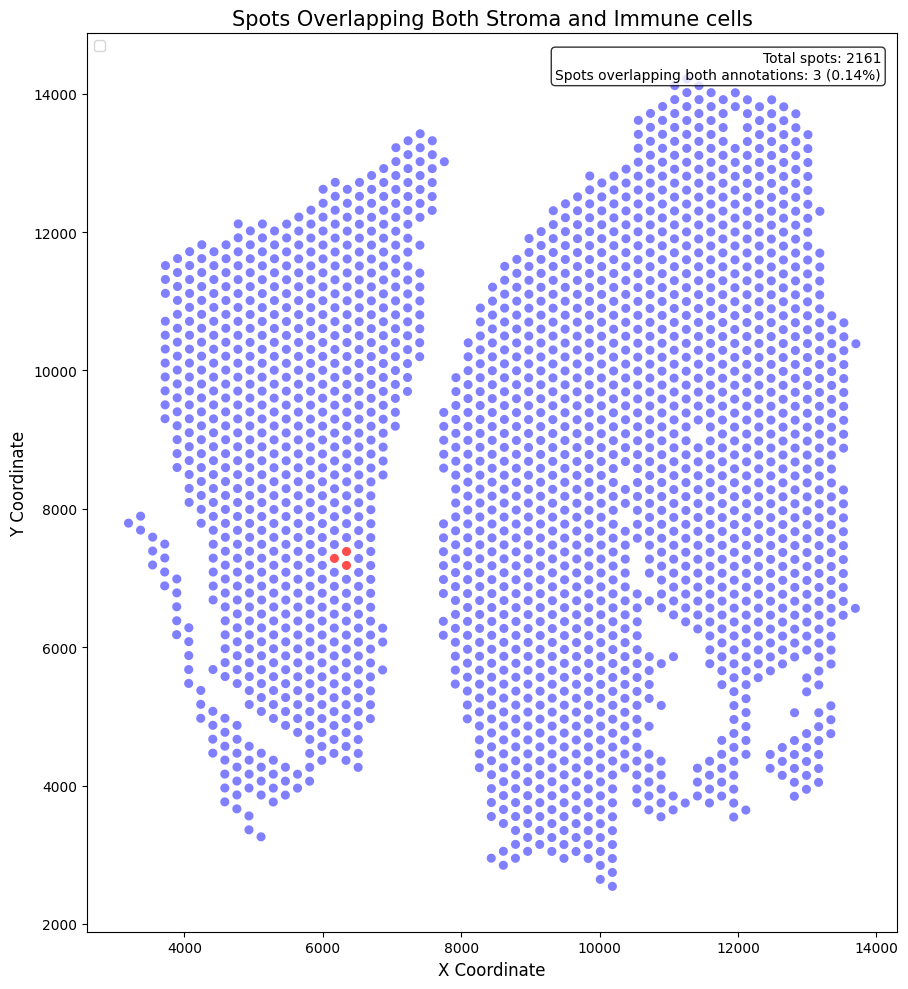

(<Figure size 1000x1000 with 1 Axes>,
 <Axes: title={'center': 'Spots Overlapping Both Stroma and Immune cells'}, xlabel='X Coordinate', ylabel='Y Coordinate'>,
       spot_id                                           geometry  \
 581       581  POLYGON ((6407.429 7383, 6407.114 7376.587, 64...   
 1548     1548  POLYGON ((6232.429 7283, 6232.114 7276.587, 62...   
 1990     1990  POLYGON ((6407.429 7182, 6407.114 7175.587, 64...   
 
       Negative_overlap  Positive_overlap  Immune cells_overlap  \
 581                0.0             100.0             21.148155   
 1548               0.0             100.0             24.455373   
 1990               0.0             100.0             83.812109   
 
       Stroma_overlap  Necrosis_overlap  Other_overlap  dual_overlap  
 581         8.069616               0.0            0.0          True  
 1548       94.958895               0.0            0.0          True  
 1990        6.052588               0.0            0.0          True  )

In [28]:
histomap.compute_overlap_annotation()
histomap.plot_combined_annotation_overlap('Stroma', 'Immune cells')

In [12]:
# Add area and generate summary
summary = histomap.generate_summary()
print(summary)
histomap.display_plot_order()

/tmp/ipykernel_100520/2447752305.py:58: UserWarning:

Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.


/tmp/ipykernel_100520/2447752305.py:59: UserWarning:

Geometry is in a geographic CRS. Results from 'length' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.


/home/croizer/anaconda3/envs/HistoMapTx2/lib/python3.13/site-packages/numpy/_core/_methods.py:57: RuntimeWarning:

overflow encountered in reduce

/home/croizer/anaconda3/envs/HistoMapTx2/lib/python3.13/site-packages/numpy/_core/_methods.py:57: RuntimeWarning:

overflow encountered in reduce

/tmp/ipykernel_100520/2447752305.py:60: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `includ

     Annotation    total_area  total_perimeter  mean_aspect_ratio  \
0  Immune cells  8.113954e+04      1393.481351       1.000000e+00   
1      Necrosis  6.438117e+06     22095.445734       1.444821e+07   
2      Negative  2.459344e+08    787391.900020                inf   
3         Other  3.592823e+06     19403.593111       1.449067e+03   
4      Positive  5.753005e+07    718000.000000                inf   
5        Stroma  1.269074e+05      2264.817610       6.405057e+02   

   mean_circularity   centroid_x   centroid_y  mean_convex_hull_area  \
0          0.525097  6261.185217  7314.721978           8.444750e+04   
1          0.620987  8881.529633  8267.151516           3.132599e+06   
2          0.527575  8867.872162  9366.450928           1.864963e+05   
3          0.347641  9348.695386  8024.431913           2.144672e+06   
4          0.570619  7389.609024  9128.652633           1.376105e+05   
5          0.702495  6332.344945  7320.703879           6.567568e+04   

   mean_bou

/tmp/ipykernel_100520/2447752305.py:86: UserWarning:

Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.


/tmp/ipykernel_100520/2447752305.py:87: UserWarning:

Geometry is in a geographic CRS. Results from 'length' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.


/tmp/ipykernel_100520/2447752305.py:88: UserWarning:

Geometry is in a geographic CRS. Results from 'length' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.




/tmp/ipykernel_100520/1070692233.py:306: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab20')


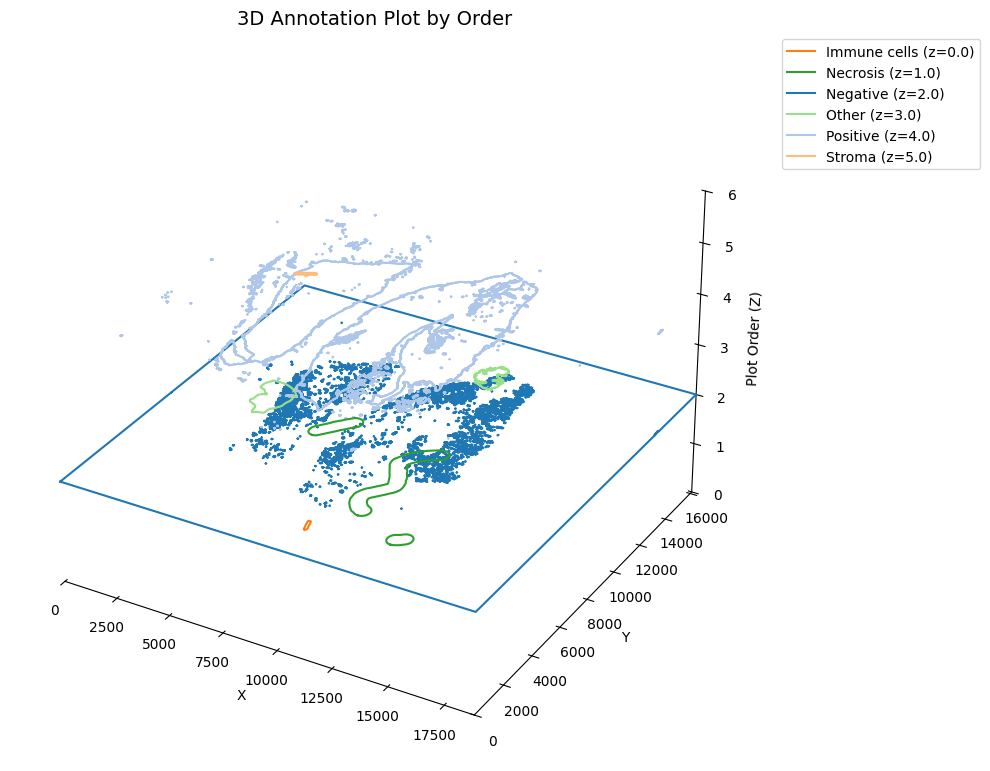

(<Figure size 1000x1000 with 1 Axes>,
 <Axes3D: title={'center': '3D Annotation Plot by Order'}, xlabel='X', ylabel='Y', zlabel='Plot Order (Z)'>)

In [6]:
# Plot annotations
histomap.plot_annotation_order()

In [7]:
!pip install nbformat

/tmp/ipykernel_100520/1070692233.py:177: MatplotlibDeprecationWarning:

The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.



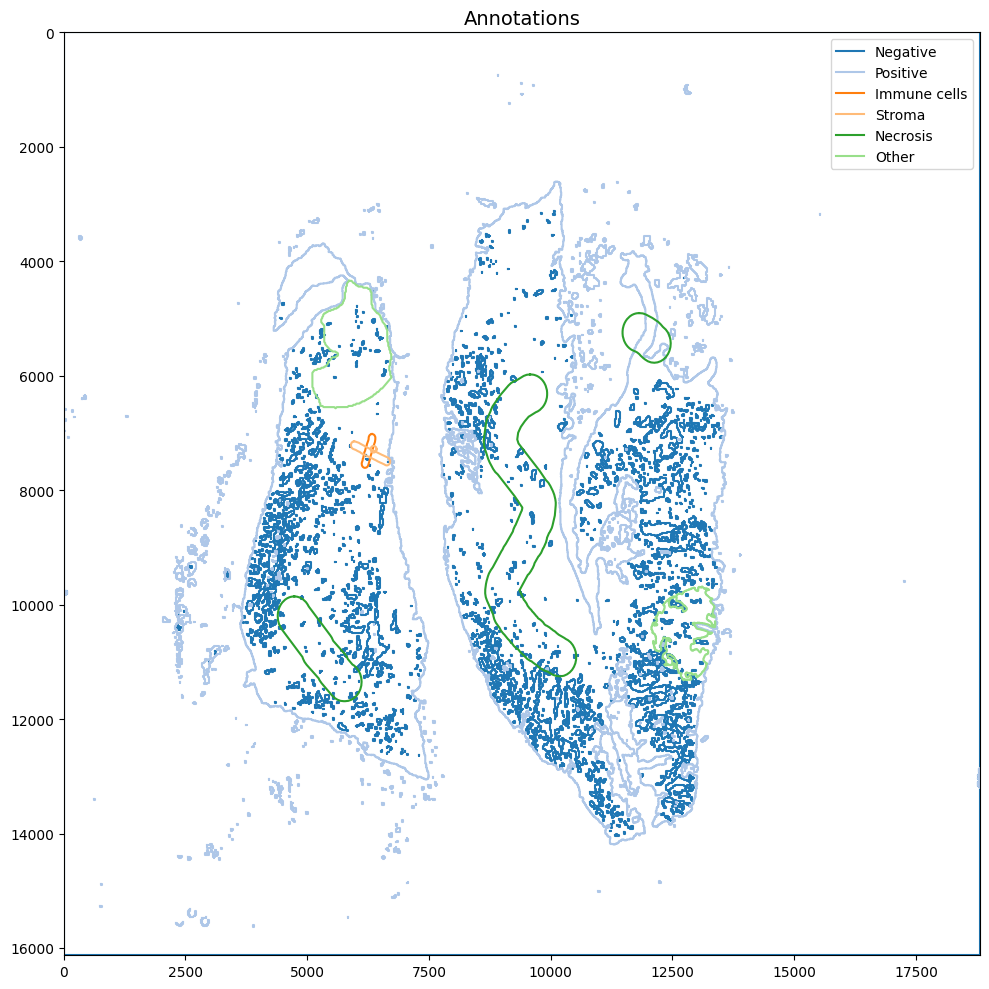

In [9]:

# Plot annotations
histomap.plot_annotations()



1/6 layer of annotation processed
2/6 layer of annotation processed
3/6 layer of annotation processed
4/6 layer of annotation processed
5/6 layer of annotation processed
6/6 layer of annotation processed


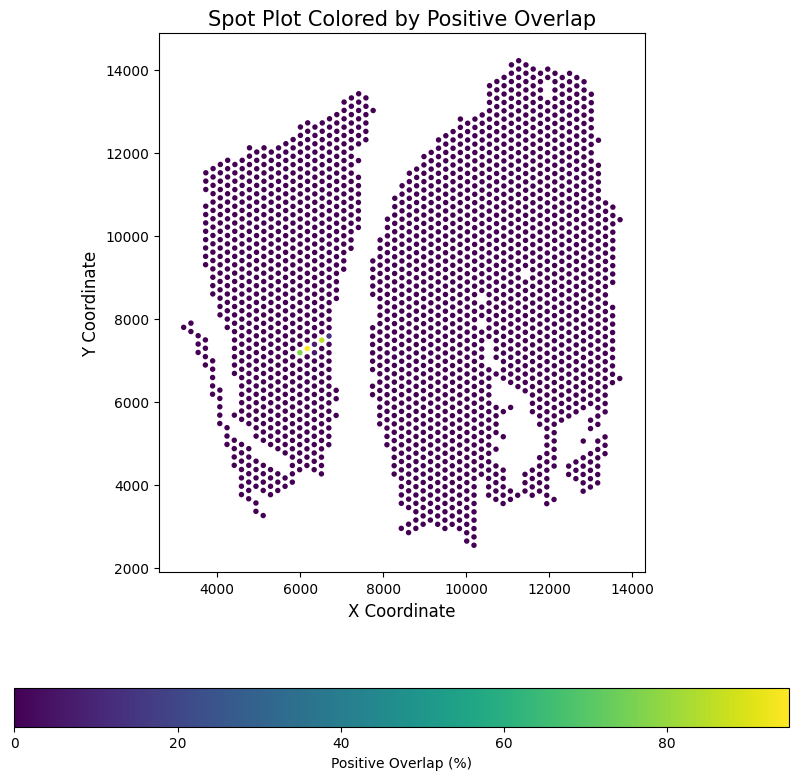

In [225]:
histomap.compute_overlap_annotation()
histomap.plot_annotation_overlay("Stroma")

In [195]:
# Load the Visium data using spatialdata_io
visium = spatialdata_io.visium('/home/croizer/Documents/Curie/ressources/4_visium_section/1_BC/2_Run2_TNBC/AO1124/', dataset_id='AO1124')

visium
list(visium.shapes.keys())[0] 

INFO     reading                                                                                                   
         /home/croizer/Documents/Curie/ressources/4_visium_section/1_BC/2_Run2_TNBC/AO1124/filtered_feature_bc_matr
         ix.h5                                                                                                     


/home/croizer/anaconda3/envs/HistoMapTx2/lib/python3.13/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/croizer/anaconda3/envs/HistoMapTx2/lib/python3.13/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/croizer/anaconda3/envs/HistoMapTx2/lib/python3.13/site-packages/spatialdata/models/models.py:1035: UserWarning: Converting `region_key: region` to categorical dtype.
  return convert_region_column_to_categorical(adata)


'AO1124'

In [87]:
# create geodataframe for the spots 
import geopandas as gpd
from shapely.geometry import Point
import numpy as np
import squidpy as sq
import scanpy as sc
import matplotlib.pyplot as plt

visium = spatialdata_io.visium('/home/croizer/Documents/Curie/ressources/4_visium_section/1_BC/2_Run2_TNBC/AO1124/', dataset_id='AO1124')
adata = sc.read_visium('/home/croizer/Documents/Curie/ressources/4_visium_section/1_BC/2_Run2_TNBC/AO1124/')
# Extract spatial coordinates
coords = adata.obsm["spatial"]

# Get spot radius (convert full-resolution diameter to radius)
spot_diameter = adata.uns["spatial"]['AO1124']["scalefactors"]["spot_diameter_fullres"]
spot_radius = spot_diameter / 2  # Radius in pixels

# Create circular polygons for each spot
gdf = gpd.GeoDataFrame(
    {"spot_id": range(len(coords))},  # Optional: Assign unique IDs
    geometry=[Point(x, y).buffer(spot_radius) for x, y in coords],  # Buffer creates circle
    #crs="EPSG:4326"  # Set CRS (adjust if needed)
)

# Display first rows
print(gdf.head())


   spot_id                                           geometry
0        0  POLYGON ((12005.429 4149, 12005.114 4142.587, ...
1        1  POLYGON ((3786.429 10107, 3786.114 10100.587, ...
2        2  POLYGON ((5701.429 4969, 5701.114 4962.587, 57...
3        3  POLYGON ((10800.429 13514, 10800.114 13507.587...
4        4  POLYGON ((11500.429 13109, 11500.114 13102.587...


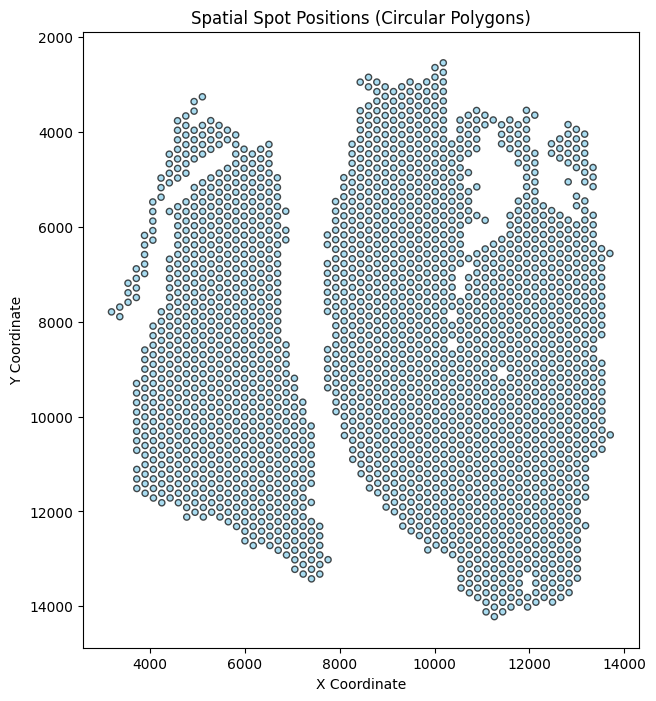

In [124]:


# Plot the GeoDataFrame with circular polygons
fig, ax = plt.subplots(figsize=(8, 8))
gdf.plot(ax=ax, color='skyblue', edgecolor='black', alpha=0.7)

# Optionally, plot a basemap or image (if available)
# If you have an image (like 'hires_image'), you can overlay it here
# For example: ax.imshow(image_data, extent=[x_min, x_max, y_min, y_max], alpha=0.5)

# Set plot labels and title
plt.xlabel("X Coordinate")
plt.ylabel("Y Coordinate")
plt.title("Spatial Spot Positions (Circular Polygons)")

# Invert Y-axis to match typical spatial imaging (optional)
plt.gca().invert_yaxis()

plt.show()


In [130]:

# Optionally, you can inspect the first few rows of the updated gdf
print(gdf.head())


1/6 layer of annotation processed
2/6 layer of annotation processed
3/6 layer of annotation processed
4/6 layer of annotation processed
5/6 layer of annotation processed
6/6 layer of annotation processed
         spot_id                                           geometry  \
spot_id                                                               
0              0  POLYGON ((12005.429 4149, 12005.114 4142.587, ...   
1              1  POLYGON ((3786.429 10107, 3786.114 10100.587, ...   
2              2  POLYGON ((5701.429 4969, 5701.114 4962.587, 57...   
3              3  POLYGON ((10800.429 13514, 10800.114 13507.587...   
4              4  POLYGON ((11500.429 13109, 11500.114 13102.587...   

         annotation_overlap  \
spot_id                       
0                 10.038599   
1                 10.909648   
2                  0.000000   
3                 42.410072   
4                 96.600000   

         {'name': 'Positive', 'color': [250, 62, 62]}_overlap  \
spot_id        

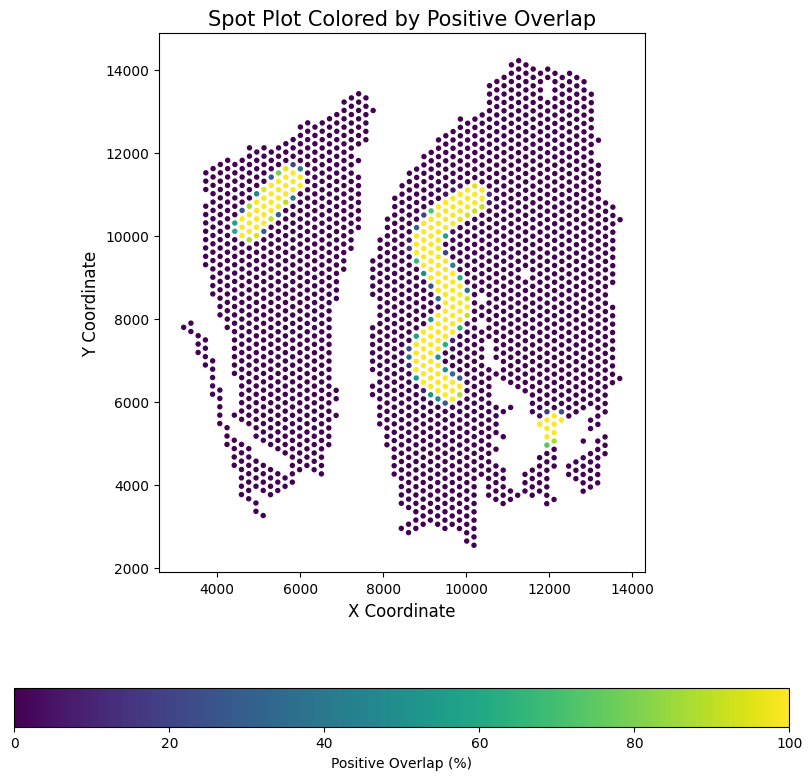

In [131]:
import matplotlib.pyplot as plt
import geopandas as gpd

# Ensure 'Positive_overlap' is in the correct format (float or int) for coloring
gdf['Positive_overlap'] = gdf['Necrosis_overlap'].astype(float)

# Plot the spots with colors based on 'Positive_overlap'
fig, ax = plt.subplots(figsize=(10, 10))  # Adjust the figure size as needed

# Plot the polygons with a colormap based on the 'Positive_overlap'
gdf.plot(ax=ax, column='Positive_overlap', cmap='viridis', legend=True,
         legend_kwds={'label': "Positive Overlap (%)",
                      'orientation': "horizontal"})

# Set title and axis labels (optional)
ax.set_title('Spot Plot Colored by Positive Overlap', fontsize=15)
ax.set_xlabel('X Coordinate', fontsize=12)
ax.set_ylabel('Y Coordinate', fontsize=12)

# Show plot
plt.show()


In [132]:
gdf

,spot_id,geometry,annotation_overlap,"{'name': 'Positive', 'color': [250, 62, 62]}_overlap","{'name': 'Negative', 'color': [112, 112, 225]}_overlap",Positive_overlap,Negative_overlap,Immune cells_overlap,Stroma_overlap,Necrosis_overlap,Other_overlap
spot_id,,,,,,,,,,,
0,0,"POLYGON ((12005.429 4149, 12005.114 4142.587, ...",10.038599,89.961401,10.038599,0.0,10.038599,0.0,0.0,0.0,0.00000
1,1,"POLYGON ((3786.429 10107, 3786.114 10100.587, ...",10.909648,89.071429,10.909648,0.0,10.909648,0.0,0.0,0.0,0.00000
2,2,"POLYGON ((5701.429 4969, 5701.114 4962.587, 57...",0.000000,100.000000,0.000000,0.0,0.000000,0.0,0.0,0.0,100.00000
3,3,"POLYGON ((10800.429 13514, 10800.114 13507.587...",42.410072,57.589928,42.410072,0.0,42.410072,0.0,0.0,0.0,0.00000
4,4,"POLYGON ((11500.429 13109, 11500.114 13102.587...",96.600000,1.009279,96.600000,0.0,96.600000,0.0,0.0,0.0,0.00000
...,...,...,...,...,...,...,...,...,...,...,...
2156,2156,"POLYGON ((7114.429 10200, 7114.114 10193.587, ...",0.000000,100.000000,0.000000,0.0,0.000000,0.0,0.0,0.0,0.00000
2157,2157,"POLYGON ((8683.429 6674, 8683.114 6667.587, 86...",0.000000,92.452978,0.000000,0.0,0.000000,0.0,0.0,0.0,0.00000
2158,2158,"POLYGON ((13420.429 10186, 13420.114 10179.587...",2.383161,69.354273,2.383161,0.0,2.383161,0.0,0.0,0.0,24.25927


# SpatialData interfacing 

## Visium frozen

/home/croizer/anaconda3/envs/HistoMapTx2/lib/python3.13/site-packages/anndata/utils.py:429: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.warn(msg, FutureWarning)


INFO     reading                                                                                                   
         /home/croizer/Documents/Curie/ressources/4_visium_section/1_BC/2_Run2_TNBC/AO1124/filtered_feature_bc_matr
         ix.h5                                                                                                     


/home/croizer/anaconda3/envs/HistoMapTx2/lib/python3.13/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/croizer/anaconda3/envs/HistoMapTx2/lib/python3.13/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/croizer/anaconda3/envs/HistoMapTx2/lib/python3.13/site-packages/spatialdata/models/models.py:1035: UserWarning: Converting `region_key: region` to categorical dtype.
  return convert_region_column_to_categorical(adata)


In [30]:
visium

SpatialData object
├── Images
│     ├── 'AO1124_hires_image': DataArray[cyx] (3, 1714, 2000)
│     └── 'AO1124_lowres_image': DataArray[cyx] (3, 514, 600)
├── Shapes
│     └── 'AO1124': GeoDataFrame shape: (2161, 2) (2D shapes)
└── Tables
      └── 'table': AnnData (2161, 36601)
with coordinate systems:
    ▸ 'downscaled_hires', with elements:
        AO1124_hires_image (Images), AO1124 (Shapes)
    ▸ 'downscaled_lowres', with elements:
        AO1124_lowres_image (Images), AO1124 (Shapes)
    ▸ 'global', with elements:
        AO1124 (Shapes)

/tmp/ipykernel_60440/136370192.py:1: FutureWarning: Use `squidpy.read.visium` instead.
  adata = sc.read_visium('/home/croizer/Documents/Curie/ressources/4_visium_section/1_BC/2_Run2_TNBC/AO1124/')
/home/croizer/anaconda3/envs/HistoMapTx2/lib/python3.13/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/croizer/anaconda3/envs/HistoMapTx2/lib/python3.13/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


## Visium HD

In [22]:
visium = spatialdata_io.visium_hd("/home/croizer/Téléchargements/Visium_HD_FF_Human_Breast_Cancer", dataset_id='Visium_HD_FF_Human_Breast_Cancer')

/tmp/ipykernel_60440/3445068690.py:1: UserWarning: No full resolution image found. If incorrect, please specify the path in the `fullres_image_file` parameter when calling the `visium_hd` reader function.
  visium = spatialdata_io.visium_hd("/home/croizer/Téléchargements/Visium_HD_FF_Human_Breast_Cancer", dataset_id='Visium_HD_FF_Human_Breast_Cancer')
